In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from pathlib import Path
import tarfile, os

archive = Path("/content/drive/MyDrive/stargan-v2/combined_balanced/afhq_all-20250824-1622.tar.gz")
dest    = Path("/content/stargan-v2")
dest.mkdir(parents=True, exist_ok=True)

# Extract the .tar.gz
with tarfile.open(archive, mode="r:gz") as tf:
    tf.extractall(path=dest)  # contents go under /content/stargan-v2/...

# Sanity checks (size + file count)
data_root = dest / "data/afhq_all"

# Count files
file_count = sum(1 for p in data_root.rglob("*") if p.is_file())

# Folder size (human-readable)
total_bytes = sum(p.stat().st_size for p in data_root.rglob("*") if p.is_file())
def hr(n):
    for u in ["B","KB","MB","GB","TB"]:
        if n < 1024: return f"{n:.1f} {u}"
        n /= 1024
    return f"{n:.1f} PB"

print("Extracted to:", data_root)
print("Files:", file_count)
print("Size:", hr(total_bytes))

# Peek a few files
print("Sample files:")
for p in list(data_root.rglob("*"))[:5]:
    if p.is_file():
        print(" -", p)


/tmp/ipython-input-1235178765.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(path=dest)  # contents go under /content/stargan-v2/...


Extracted to: /content/stargan-v2/data/afhq_all
Files: 0
Size: 0.0 B
Sample files:


In [ ]:
from pathlib import Path
import tarfile, os

archive = Path("/content/drive/MyDrive/stargan-v2/afhq_all-20250824-0532.tar.gz")
dest    = Path("/content/stargan-v2")
dest.mkdir(parents=True, exist_ok=True)

# Extract the .tar.gz
with tarfile.open(archive, mode="r:gz") as tf:
    tf.extractall(path=dest)  # contents go under /content/stargan-v2/...

# Sanity checks (size + file count)
data_root = dest / "data/afhq_all"

# Count files
file_count = sum(1 for p in data_root.rglob("*") if p.is_file())

# Folder size
total_bytes = sum(p.stat().st_size for p in data_root.rglob("*") if p.is_file())
def hr(n):
    for u in ["B","KB","MB","GB","TB"]:
        if n < 1024: return f"{n:.1f} {u}"
        n /= 1024
    return f"{n:.1f} PB"

print("Extracted to:", data_root)
print("Files:", file_count)
print("Size:", hr(total_bytes))

# Peek a few files
print("Sample files:")
for p in list(data_root.rglob("*"))[:5]:
    if p.is_file():
        print(" -", p)


/tmp/ipython-input-3331895069.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(path=dest)  # contents go under /content/stargan-v2/...


Extracted to: /content/stargan-v2/data/afhq_all
Files: 0
Size: 0.0 B
Sample files:


In [ ]:
# --- SETTINGS ---
IMG_SIZE = 256  # StarGAN v2 default; change if you sampled with another size

from pathlib import Path
from PIL import Image
import os, pandas as pd, re

base_drive = Path("/content/stargan-v2")
in_root    = base_drive/"expr/results/afhq_all_fake_stargan"
out_root   = base_drive/"expr/results/afhq_all_fake_tiles"
meta_path  = base_drive/"data/afhq_all_metadata.csv"
splits     = ["train","val","holdout"]

out_root.mkdir(parents=True, exist_ok=True)
new_rows = []

def slice_grid(ref_path: Path, split: str):
    img = Image.open(ref_path).convert("RGB")
    W, H = img.size
    cols = W // IMG_SIZE
    rows = H // IMG_SIZE
    if cols == 0 or rows == 0:
        print(f"[WARN] {ref_path} not divisible by {IMG_SIZE}; skipping.")
        return 0
    # Save tiles
    out_dir = out_root/split
    out_dir.mkdir(parents=True, exist_ok=True)
    saved = 0
    for r in range(rows):
        for c in range(cols):
            # If you want to SKIP the first column (often the source image), uncomment:
            if c == 0: continue
            tile = img.crop((c*IMG_SIZE, r*IMG_SIZE, (c+1)*IMG_SIZE, (r+1)*IMG_SIZE))
            fname = f"{split}_r{r:04d}_c{c:04d}.png"
            fpath = out_dir/fname
            tile.save(fpath, "PNG")
            new_rows.append({
                "id": fpath.stem,
                "path": str(fpath),
                "split": split,
                "species_src": "",         # unknown from grid; leave blank
                "species_tgt": "",
                "label": "fake",
                "gen_family": "stargan_v2",
                "seed": "",
                "ref_id": "",
                "source": "generated_grid"
            })
            saved += 1
    return saved

total_saved = 0
for sp in splits:
    ref = in_root/f"{sp}_all"/"reference.jpg"
    if ref.exists():
        print(f"Slicing {ref} ...")
        total_saved += slice_grid(ref, sp)
    else:
        print(f"[INFO] No {ref} (did sampling finish for {sp}?)")

print(f"\nSaved {total_saved} tiles to {out_root}")

# Append to metadata (creating it if missing)
"""
if meta_path.exists():
    df = pd.read_csv(meta_path)
else:
    df = pd.DataFrame(columns=["id","path","split","species_src","species_tgt",
                               "label","gen_family","seed","ref_id","source"])
df_new = pd.DataFrame(new_rows)
df_all = pd.concat([df, df_new], ignore_index=True)
df_all.to_csv(meta_path, index=False)
print(f"Updated metadata: {meta_path} (rows={len(df_all)})")
"""

Slicing /content/stargan-v2/expr/results/afhq_all_fake_stargan/train_all/reference.jpg ...
Slicing /content/stargan-v2/expr/results/afhq_all_fake_stargan/val_all/reference.jpg ...
Slicing /content/stargan-v2/expr/results/afhq_all_fake_stargan/holdout_all/reference.jpg ...

Saved 2976 tiles to /content/stargan-v2/expr/results/afhq_all_fake_tiles


'\nif meta_path.exists():\n    df = pd.read_csv(meta_path)\nelse:\n    df = pd.DataFrame(columns=["id","path","split","species_src","species_tgt",\n                               "label","gen_family","seed","ref_id","source"])\ndf_new = pd.DataFrame(new_rows)\ndf_all = pd.concat([df, df_new], ignore_index=True)\ndf_all.to_csv(meta_path, index=False)\nprint(f"Updated metadata: {meta_path} (rows={len(df_all)})")\n'

In [ ]:
from pathlib import Path
import tarfile, os

archive = Path("/content/drive/MyDrive/stargan-v2/afhq_all-20250824-0541.tar.gz")
dest    = Path("/content/stargan-v2")
dest.mkdir(parents=True, exist_ok=True)

# Extract the .tar.gz
with tarfile.open(archive, mode="r:gz") as tf:
    tf.extractall(path=dest)  # contents go under /content/stargan-v2/...

# Sanity checks (size + file count)
data_root = dest / "data/afhq_all"

# Count files
file_count = sum(1 for p in data_root.rglob("*") if p.is_file())

# Folder size (human-readable)
total_bytes = sum(p.stat().st_size for p in data_root.rglob("*") if p.is_file())
def hr(n):
    for u in ["B","KB","MB","GB","TB"]:
        if n < 1024: return f"{n:.1f} {u}"
        n /= 1024
    return f"{n:.1f} PB"

print("Extracted to:", data_root)
print("Files:", file_count)
print("Size:", hr(total_bytes))

# Peek a few files
print("Sample files:")
for p in list(data_root.rglob("*"))[:5]:
    if p.is_file():
        print(" -", p)


/tmp/ipython-input-2479020740.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(path=dest)  # contents go under /content/stargan-v2/...


Extracted to: /content/stargan-v2/data/afhq_all
Files: 0
Size: 0.0 B
Sample files:


In [ ]:
# ===========================
# BoVW + PCA + KMeans (TRAIN)
# ===========================
# - Pre-preprocessing metrics for ALL images: width, height, aspect_ratio,
#   brightness, contrast, sharpness_l1_mean (no resizing).
# - Preprocess for BoVW: grayscale + resize (max side).
# - Auto-select codebook K (from small grid) via 3-fold AUROC using LogisticRegression.
# - Auto-select PCA dims to hit variance threshold and confirm via AUROC grid.
# - Image-level KMeans: auto-select k via silhouette over grid AND always save k=10.
# - Correlation/diagnostics: silhouette table, χ² + Cramér's V (cluster↔fake),
#   point-biserial correlations (PCA↔fake), ratio tables by real/fake/species/technique.
# - Outputs:
#   - CSV: /content/stargan-v2/bovw/image_features.csv
#   - NPY/JOBLIB artifacts in /content/stargan-v2/bovw/

import os, sys, math, gc, hashlib, json, warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
from tqdm import tqdm

import cv2
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, silhouette_score
from scipy.stats import chi2_contingency, pearsonr

import joblib

warnings.filterwarnings("ignore", category=FutureWarning)

# -------------------
# Paths / Config
# -------------------
TRAIN_ROOT = Path("/content/stargan-v2/data/combined_balanced/train")  # {real,fake}
REAL_SRC   = Path("/content/stargan-v2/data/afhq_all/train")           # {cat,dog,wild}
FAKE_SOURCES = {
    "stargan_tiles": Path("/content/stargan-v2/expr/results/afhq_all_fake_tiles/train"),
    "copy_move":     Path("/content/stargan-v2/expr/results/fake_copy_move/train"),
    "inpaint":       Path("/content/stargan-v2/expr/results/fake_inpaint/train"),
    "postproc":      Path("/content/stargan-v2/expr/results/fake_postproc/train"),
    "splicing":      Path("/content/stargan-v2/expr/results/fake_splicing/train"),
    "swap_like":     Path("/content/stargan-v2/expr/results/fake_swap_like/train"),
}

OUT_DIR = Path("/content/stargan-v2/bovw")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CLASSES  = ["real","fake"]
SPECIES  = ["cat","dog","wild"]
EXTS     = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}

# Preprocessing for BoVW
MAX_SIDE = 512
USE_SIFT = True

# BoVW codebook search
CODEBOOK_K_CANDIDATES = [128, 256]         # keep small to control runtime; adjust if needed
MAX_DESCS_PER_IMAGE   = 500
MAX_TOTAL_DESCRIPTORS = 200_000
MBKMEANS_BATCH        = 4096

# PCA selection
PCA_VAR_TARGET   = 0.90                     # target cumulative explained variance
PCA_DIM_CAND     = [64, 96, 128]            # will be clipped to <= K

# Image-level KMeans (on PCA features)
IMG_K_GRID       = [2, 3, 5, 10, 20, 50]
ALWAYS_K10       = 10

RNG = 42
np.random.seed(RNG)

# -------------------
# Helpers
# -------------------
def list_images(root: Path):
    return [p for p in root.glob("*") if p.suffix.lower() in EXTS and p.is_file()]

def load_bgr(p: Path):
    img = cv2.imread(str(p), cv2.IMREAD_COLOR)
    return img

def grayscale_and_resize(img_bgr, max_side=MAX_SIDE):
    h, w = img_bgr.shape[:2]
    s = max(h, w)
    if s > max_side:
        scale = max_side / float(s)
        img_bgr = cv2.resize(img_bgr, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return gray

def pre_stats(img_bgr):
    h, w = img_bgr.shape[:2]
    g = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    # brightness/contrast on original
    brightness = float(g.mean())
    contrast   = float(g.std())
    # sharpness L1 mean via Sobel |gx| + |gy|
    gx = cv2.Sobel(g, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(g, cv2.CV_32F, 0, 1, ksize=3)
    sharp_l1_mean = float(np.mean(np.abs(gx)) + np.mean(np.abs(gy)))
    return {
        "width": int(w),
        "height": int(h),
        "aspect_ratio": float(w)/float(h) if h > 0 else np.nan,
        "brightness": brightness,
        "contrast": contrast,
        "sharpness_l1_mean": sharp_l1_mean,
    }

def get_detector():
    if USE_SIFT:
        try:
            return cv2.SIFT_create(), "SIFT", 128
        except Exception:
            pass
    orb = cv2.ORB_create(nfeatures=1000, fastThreshold=10)
    return orb, "ORB", 32

def extract_desc(detector, gray, dim):
    kps, desc = detector.detectAndCompute(gray, None)
    if desc is None or len(kps) == 0:
        return np.zeros((0, dim), dtype=np.float32)
    desc = desc.astype(np.float32)
    return desc

def tf_idf_weight(H):
    N = H.shape[0]
    df = (H > 0).sum(axis=0)
    idf = np.log((N + 1) / (df + 1)) + 1.0
    return H * idf

def sha1_file(p, chunk=1<<20):
    h = hashlib.sha1()
    with open(p, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""):
            h.update(b)
    return h.hexdigest()

# -------------------
# 0) Gather train paths + labels
# -------------------
paths, labels = [], []
for ci, cls in enumerate(CLASSES):
    d = TRAIN_ROOT/cls
    assert d.exists(), f"Missing: {d}"
    ps = list_images(d)
    paths.extend(ps)
    labels.extend([ci]*len(ps))

print(f"Found TRAIN: real={labels.count(0)} fake={labels.count(1)} total={len(paths)}")
assert len(paths)>0

# -------------------
# A) Pre-preprocessing metrics (all images)
# -------------------
pre_rows = []
print("Computing pre-preprocessing stats (ALL images)...")
for p, lab in tqdm(list(zip(paths, labels)), total=len(paths)):
    img = load_bgr(p)
    if img is None:
        continue
    s = pre_stats(img)
    s["path"]  = str(p)
    s["label"] = int(lab)  # 0=real,1=fake
    pre_rows.append(s)

pre_df = pd.DataFrame(pre_rows)
print("Pre-stats rows:", len(pre_df))

# -------------------
# B) Map species / fake_technique by hashing (optional enrichment)
# -------------------
def index_source_dir(root: Path, tag_kind: str, tag_value: str, limit_per_dir=None):
    """Return {sha1: {tag_kind: tag_value, 'species': species?}} mapping."""
    out = {}
    if tag_kind == "species":  # real tree
        for sp in SPECIES:
            d = root/sp
            if not d.exists():
                continue
            ps = list_images(d)
            if limit_per_dir: ps = ps[:limit_per_dir]
            for p in ps:
                try:
                    out[sha1_file(p)] = {"species": sp}
                except Exception:
                    pass
    else:  # fake tree with species subdirs
        for sp in SPECIES:
            d = root/sp
            if not d.exists():
                continue
            ps = list_images(d)
            if limit_per_dir: ps = ps[:limit_per_dir]
            for p in ps:
                try:
                    out[sha1_file(p)] = {"species": sp, "fake_technique": tag_value}
                except Exception:
                    pass
    return out

print("Indexing source trees to recover species/fake_technique...")
HASH_MAX_PER_DIR = None  # set to an int to limit indexing per subdir
hash_map = {}

# Real species
hash_map.update(index_source_dir(REAL_SRC, "species", "", limit_per_dir=HASH_MAX_PER_DIR))

# Fake techniques
for tech, root in FAKE_SOURCES.items():
    if root.exists():
        part = index_source_dir(root, "fake_technique", tech, limit_per_dir=HASH_MAX_PER_DIR)
        # Prefer the first match (rare hash collisions aside)
        for h, meta in part.items():
            hash_map.setdefault(h, meta)

# Attach metadata to train images
species_list, tech_list = [], []
print("Hashing train images to look up species/technique...")
for p, lab in tqdm(list(zip(paths, labels)), total=len(paths)):
    try:
        h = sha1_file(p)
        meta = hash_map.get(h, {})
        species_list.append(meta.get("species", "unknown"))
        tech_list.append(meta.get("fake_technique", "none" if lab==0 else "unknown"))
    except Exception:
        species_list.append("unknown")
        tech_list.append("none" if lab==0 else "unknown")

# Merge into pre_df
pre_df["species"] = species_list
pre_df["fake_technique"] = tech_list

# -------------------
# C) Descriptor gathering for codebook selection
# -------------------
det, det_name, desc_dim = get_detector()
print("Using detector:", det_name)

def gather_descriptors(sample_paths):
    all_descs, total = [], 0
    for p in tqdm(sample_paths, desc="Gathering desc", total=len(sample_paths)):
        img = load_bgr(p)
        if img is None:
            continue
        gray = grayscale_and_resize(img, MAX_SIDE)
        desc = extract_desc(det, gray, desc_dim)
        if desc.shape[0]==0:
            continue
        if desc.shape[0] > MAX_DESCS_PER_IMAGE:
            idx = np.random.choice(desc.shape[0], MAX_DESCS_PER_IMAGE, replace=False)
            desc = desc[idx]
        all_descs.append(desc)
        total += desc.shape[0]
        if total >= MAX_TOTAL_DESCRIPTORS:
            break
    if not all_descs:
        raise RuntimeError("No descriptors available for codebook.")
    X_code = np.vstack(all_descs).astype(np.float32)
    return X_code

X_code = gather_descriptors(paths)
print("Descriptor matrix for codebook:", X_code.shape)

# -------------------
# D) Fit codebooks, build BoVW, select best K via CV AUROC
# -------------------
def build_bovw_hist(all_paths, kmeans):
    K = kmeans.n_clusters
    H = np.zeros((len(all_paths), K), dtype=np.float32)
    for i, p in enumerate(tqdm(all_paths, desc=f"BoVW(K={K})", total=len(all_paths))):
        img = load_bgr(p)
        if img is None:
            continue
        gray = grayscale_and_resize(img, MAX_SIDE)
        desc = extract_desc(det, gray, desc_dim)
        if desc.shape[0] == 0:
            continue
        words = kmeans.predict(desc)
        H[i] = np.bincount(words, minlength=K).astype(np.float32)
    # TF-IDF + L2
    H = tf_idf_weight(H)
    H = normalize(H, norm="l2")
    return H

def cv_auroc(X, y):
    # Standardize + LogisticRegression
    scaler = StandardScaler(with_mean=True, with_std=True)
    Xs = scaler.fit_transform(X)
    lr = LogisticRegression(
        solver="saga", penalty="l2", C=1.0, max_iter=2000, random_state=RNG, n_jobs=1
    )
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RNG)
    scores = cross_val_score(lr, Xs, y, cv=cv, scoring="roc_auc", n_jobs=1)
    return float(scores.mean()), float(scores.std())

y = np.array(labels, dtype=np.int64)
bovw_by_k = {}
cv_table = []

for K in CODEBOOK_K_CANDIDATES:
    print(f"Fitting MiniBatchKMeans codebook K={K} ...")
    mbk = MiniBatchKMeans(n_clusters=K, random_state=RNG, batch_size=MBKMEANS_BATCH, reassignment_ratio=0.01)
    mbk.fit(X_code)
    H = build_bovw_hist(paths, mbk)
    mean_auc, std_auc = cv_auroc(H, y)
    print(f"  -> CV AUROC (K={K}): {mean_auc:.3f} ± {std_auc:.3f}")
    bovw_by_k[K] = (mbk, H, mean_auc)
    cv_table.append({"K_codebook": K, "cv_auroc": mean_auc})

# pick best K by AUROC
best_K = max(cv_table, key=lambda r: r["cv_auroc"])["K_codebook"]
kmeans_codebook, H_norm, best_auc = bovw_by_k[best_K]
print(f"[SELECT] Codebook K={best_K} (CV AUROC={best_auc:.3f})")

joblib.dump(kmeans_codebook, OUT_DIR/f"kmeans_codebook_{det_name}_K{best_K}.joblib")
np.save(OUT_DIR/f"H_bovw_{det_name}_K{best_K}_train.npy", H_norm)

# -------------------
# E) PCA selection
# -------------------
pca_dim_cands = [d for d in PCA_DIM_CAND if d <= best_K]
pca_dim_auto  = None

# Fit one PCA big enough (<= best_K) to compute explained variance
pca_probe = PCA(n_components=min(best_K, max(pca_dim_cands) if pca_dim_cands else best_K), random_state=RNG)
X_probe = pca_probe.fit_transform(H_norm)
cumvar = np.cumsum(pca_probe.explained_variance_ratio_)
pca_dim_auto = int(np.searchsorted(cumvar, PCA_VAR_TARGET) + 1)
pca_dim_auto = min(pca_dim_auto, best_K)
print(f"Explained variance target {PCA_VAR_TARGET:.2f} -> PCA dims auto = {pca_dim_auto}")

dims_to_test = sorted(set(pca_dim_cands + [pca_dim_auto]))
pca_cv = []
for d in dims_to_test:
    pca = PCA(n_components=d, random_state=RNG)
    Xp = pca.fit_transform(H_norm)
    auc_mean, auc_std = cv_auroc(Xp, y)
    print(f"  PCA {d:>3d} -> CV AUROC={auc_mean:.3f} ± {auc_std:.3f}")
    pca_cv.append({"pca_dims": d, "cv_auroc": auc_mean})

best_pca_dims = max(pca_cv, key=lambda r: r["cv_auroc"])["pca_dims"]
pca_final = PCA(n_components=best_pca_dims, random_state=RNG)
X_pca = pca_final.fit_transform(H_norm)
print(f"[SELECT] PCA dims={best_pca_dims} (cumvar={pca_final.explained_variance_ratio_.sum():.3f})")

joblib.dump(pca_final, OUT_DIR/f"pca_{det_name}_K{best_K}_to{best_pca_dims}.joblib")
np.save(OUT_DIR/f"X_pca_{det_name}_K{best_K}_D{best_pca_dims}_train.npy", X_pca)

# -------------------
# F) Image-level KMeans (on PCA) + always k=10
# -------------------
sil_table = []
km_labels_by_k = {}
for k in IMG_K_GRID:
    km = KMeans(n_clusters=k, random_state=RNG, n_init="auto")
    labs = km.fit_predict(X_pca)
    # silhouette only defined if k>1 and cluster sizes not degenerate
    sil = silhouette_score(X_pca, labs) if k>1 and len(set(labs))>1 else np.nan
    sil_table.append({"k": k, "silhouette": float(sil)})
    km_labels_by_k[k] = labs
    np.save(OUT_DIR/f"km_img_labels_k{k}.npy", labs)

# select best k by silhouette
sil_df = pd.DataFrame(sil_table).sort_values("k")
k_best = sil_df.iloc[sil_df["silhouette"].idxmax()]["k"]
print("Silhouette table:\n", sil_df.to_string(index=False))
print(f"[SELECT] image-level KMeans k={int(k_best)} by silhouette")

# Always also produce k=10
labs_kbest = km_labels_by_k[int(k_best)]
labs_k10   = km_labels_by_k.get(ALWAYS_K10, None)
if labs_k10 is None:
    km10 = KMeans(n_clusters=ALWAYS_K10, random_state=RNG, n_init="auto")
    labs_k10 = km10.fit_predict(X_pca)
    np.save(OUT_DIR/f"km_img_labels_k{ALWAYS_K10}.npy", labs_k10)

# -------------------
# G) Correlations & ratios
# -------------------
df = pre_df.copy()
df["bovw_K"]       = best_K
df["pca_dims"]     = best_pca_dims
df["km_k_best"]    = int(k_best)
df["km_label_best"]= labs_kbest
df["km_label_k10"] = labs_k10
df["label_name"]   = df["label"].map({0:"real",1:"fake"})

# PCA ↔ fake: point-biserial (Pearson with binary)
pvals = []
for j in range(best_pca_dims):
    r, p = pearsonr(X_pca[:, j], y)
    pvals.append((j, r, p))
pca_corr_df = pd.DataFrame(pvals, columns=["pc","pearson_r","p_value"]).sort_values("pearson_r", key=np.abs, ascending=False)
print("\nTop 10 PCs by |corr| with fake:")
print(pca_corr_df.head(10).to_string(index=False))

# Cluster ↔ fake: χ² + Cramér’s V
def cramers_v(conf_mat):
    chi2, p, dof, exp = chi2_contingency(conf_mat)
    n = conf_mat.sum().sum()
    k_min = min(conf_mat.shape) - 1
    V = math.sqrt(chi2 / (n * k_min)) if k_min>0 else 0.0
    return chi2, p, V

ct = pd.crosstab(df["km_label_best"], df["label_name"])
chi2, pchi, V = cramers_v(ct)
print(f"\nKMeans(k={int(k_best)}) χ²={chi2:.2f}, p={pchi:.3g}, Cramér’s V={V:.3f}")

# Ratios per cluster (best k)
cluster_comp = ct.copy()
cluster_comp["total"] = cluster_comp.sum(axis=1)
cluster_comp["fake_ratio"] = cluster_comp["fake"] / cluster_comp["total"].clip(lower=1)
print("\nCluster composition (best k) head:")
print(cluster_comp.head(10).to_string())

# Ratios by species / technique inside clusters (best k)
if "species" in df.columns:
    spec_tab = pd.crosstab([df["km_label_best"], df["species"]], df["label_name"])
else:
    spec_tab = pd.DataFrame()
if "fake_technique" in df.columns:
    tech_tab = pd.crosstab([df["km_label_best"], df["fake_technique"]], df["label_name"])
else:
    tech_tab = pd.DataFrame()

# PCA bin ratios (use first two PCs, 4 quantile bins each)
bins = 4
pc1_bins = pd.qcut(X_pca[:,0], q=bins, duplicates="drop")
pc2_bins = pd.qcut(X_pca[:,1], q=bins, duplicates="drop")
pca_bin_tab = pd.crosstab([pc1_bins, pc2_bins], df["label_name"])
pca_bin_ratio = (pca_bin_tab["fake"] / pca_bin_tab.sum(axis=1)).rename("fake_ratio").reset_index()

# -------------------
# H) (Optional) write BoVW and PCA columns into CSV (wide)
# -------------------
# NOTE: This makes a wide CSV; you can disable BoVW columns if file size is a concern.
include_bovw_in_csv = True
include_pca_in_csv  = True

cols = [
    "path","label","label_name","species","fake_technique",
    "width","height","aspect_ratio","brightness","contrast","sharpness_l1_mean",
    "bovw_K","pca_dims","km_k_best","km_label_best","km_label_k10"
]

data = {c: df[c].values for c in cols}

if include_bovw_in_csv:
    # Save the normalized BoVW (H_norm) columns
    for j in range(H_norm.shape[1]):
        data[f"bovw_{j}"] = H_norm[:, j]
if include_pca_in_csv:
    for j in range(best_pca_dims):
        data[f"pca_{j}"] = X_pca[:, j]

df_out = pd.DataFrame(data)
csv_path = OUT_DIR/"image_features.csv"
df_out.to_csv(csv_path, index=False)
print(f"\nWrote CSV: {csv_path}")
print("Rows:", len(df_out), "Cols:", df_out.shape[1])

# Also save handy summary tables
pd.DataFrame(cv_table).to_csv(OUT_DIR/"cv_bovw_k_selection.csv", index=False)
pd.DataFrame(pca_cv).to_csv(OUT_DIR/"cv_pca_selection.csv", index=False)
sil_df.to_csv(OUT_DIR/"silhouette_k_grid.csv", index=False)
cluster_comp.to_csv(OUT_DIR/"cluster_composition_bestk.csv")
if not spec_tab.empty:
    spec_tab.to_csv(OUT_DIR/"cluster_by_species_bestk.csv")
if not tech_tab.empty:
    tech_tab.to_csv(OUT_DIR/"cluster_by_technique_bestk.csv")
pca_corr_df.to_csv(OUT_DIR/"pca_component_correlations.csv", index=False)
pca_bin_ratio.to_csv(OUT_DIR/"pca_bin_fake_ratios.csv", index=False)

print("\n=== DONE ===")
print(f"Selected: Codebook K={best_K} | PCA dims={best_pca_dims} | KMeans best k={int(k_best)} (+ saved k=10)")


Found TRAIN: real=2726 fake=2778 total=5504
Computing pre-preprocessing stats (ALL images)...


100%|██████████| 5504/5504 [00:40<00:00, 136.73it/s]


Pre-stats rows: 5504
Indexing source trees to recover species/fake_technique...
Hashing train images to look up species/technique...


100%|██████████| 5504/5504 [00:01<00:00, 3054.73it/s]


Using detector: SIFT


...

Descriptor matrix for codebook: (200057, 128)
Fitting MiniBatchKMeans codebook K=128 ...


BoVW(K=128): 100%|██████████| 5504/5504 [11:53<00:00,  7.71it/s]


  -> CV AUROC (K=128): 0.647 ± 0.009
Fitting MiniBatchKMeans codebook K=256 ...


BoVW(K=256): 100%|██████████| 5504/5504 [11:58<00:00,  7.66it/s]


  -> CV AUROC (K=256): 0.641 ± 0.010
[SELECT] Codebook K=128 (CV AUROC=0.647)
Explained variance target 0.90 -> PCA dims auto = 83
  PCA  64 -> CV AUROC=0.659 ± 0.011
  PCA  83 -> CV AUROC=0.656 ± 0.010
  PCA  96 -> CV AUROC=0.653 ± 0.010
  PCA 128 -> CV AUROC=0.647 ± 0.009
[SELECT] PCA dims=64 (cumvar=0.847)
Silhouette table:
  k  silhouette
 2    0.150937
 3    0.129710
 5    0.094422
10    0.073157
20    0.057036
50    0.038912
[SELECT] image-level KMeans k=2 by silhouette

Top 10 PCs by |corr| with fake:
 pc  pearson_r      p_value
 10  -0.125613 8.436107e-21
  1  -0.119598 5.444432e-19
  4  -0.089685 2.636883e-11
  9  -0.089427 3.006051e-11
  7   0.078670 5.091799e-09
 17  -0.078661 5.112352e-09
  6  -0.068763 3.285148e-07
  8   0.067380 5.633291e-07
  2  -0.067259 5.900937e-07
  3   0.065932 9.799584e-07

KMeans(k=2) χ²=0.15, p=0.695, Cramér’s V=0.005

Cluster composition (best k) head:
label_name     fake  real  total  fake_ratio
km_label_best                               
0   

In [ ]:
# BoVW + KMeans + PCA on the TRAIN split
# - Scans /content/stargan-v2/data/combined_balanced/train/{real,fake}
# - Extracts local descriptors (SIFT if available, else ORB)
# - Learns a visual codebook with MiniBatch KMeans (BoVW)
# - Builds per-image histograms (TF-IDF + L2 normalized)
# - Reduces dimensionality with PCA
# - Saves features/labels + models under /content/stargan-v2/bovw/

import os, random, math, gc
from pathlib import Path
import numpy as np
import cv2
from tqdm import tqdm
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
import joblib

# -------------------
# Config
# -------------------
TRAIN_ROOT = Path("/content/stargan-v2/data/combined_balanced/train")  # change if needed
CLASSES    = ["real", "fake"]
EXTS       = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

# Feature & codebook
USE_SIFT               = True   # Try SIFT first (requires opencv-contrib). Falls back to ORB automatically.
MAX_SIDE               = 512    # Resize longer side down to this (speed)
MAX_IMAGES_PER_CLASS   = None   # cap for quick tests (e.g., 2000). None = all
K                      = 256    # codebook size (visual words)
MAX_DESCS_PER_IMAGE    = 500    # sample per image (for codebook fitting)
MAX_TOTAL_DESCRIPTORS  = 200_000  # global cap for codebook fitting (memory guard)
BATCH_SIZE             = 4096   # MiniBatchKMeans batch size

# Histograms
USE_TFIDF  = True      # apply IDF weighting to BoVW histograms
PCA_DIMS   = 128       # PCA target dims (<= K is typical)
RNG_SEED   = 42

OUT_DIR = Path("/content/stargan-v2/bovw")
OUT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

# -------------------
# Helpers
# -------------------
def list_images(root: Path, cls: str):
    d = root / cls
    if not d.exists():
        return []
    imgs = [p for p in d.iterdir() if p.is_file() and p.suffix.lower() in EXTS]
    if MAX_IMAGES_PER_CLASS is not None:
        imgs = imgs[:MAX_IMAGES_PER_CLASS]
    return imgs

def load_gray_resize(p: Path, max_side=MAX_SIDE):
    img = cv2.imread(str(p), cv2.IMREAD_COLOR)
    if img is None:
        return None
    h, w = img.shape[:2]
    s = max(h, w)
    if s > max_side:
        scale = max_side / float(s)
        img = cv2.resize(img, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray

def get_detector():
    # Try SIFT (opencv-contrib); else fall back to ORB
    if USE_SIFT:
        try:
            sift = cv2.SIFT_create()
            return sift, "SIFT"
        except Exception:
            pass
    orb = cv2.ORB_create(nfeatures=1000, fastThreshold=10)
    return orb, "ORB"

def extract_desc(detector, gray):
    # Returns NxD float32 descriptor array (may be empty)
    kps, desc = detector.detectAndCompute(gray, None)
    if desc is None or len(kps) == 0:
        return np.empty((0, 128 if hasattr(detector, "descriptorSize") else 32), dtype=np.float32)
    # Convert to float32 for KMeans
    if desc.dtype != np.float32:
        desc = desc.astype(np.float32)
    return desc

def tf_idf_weight(H):
    # H: (N, K) raw counts
    N = H.shape[0]
    df = (H > 0).sum(axis=0)  # document frequency per word
    idf = np.log((N + 1) / (df + 1)) + 1.0  # smooth IDF
    return H * idf

# -------------------
# 1) Gather image paths
# -------------------
paths, labels = [], []
for ci, cls in enumerate(CLASSES):
    imgs = list_images(TRAIN_ROOT, cls)
    paths.extend(imgs)
    labels.extend([ci] * len(imgs))

print(f"Found: real={labels.count(0)}  fake={labels.count(1)}  total={len(paths)}")
assert len(paths) > 0, "No images found in TRAIN_ROOT."

# -------------------
# 2) Extract descriptors for codebook (sampled)
# -------------------
det, det_name = get_detector()
print("Using detector:", det_name)

all_descs = []
desc_count = 0

print("Collecting descriptors for codebook...")
for p in tqdm(paths, total=len(paths)):
    gray = load_gray_resize(p)
    if gray is None:
        continue
    desc = extract_desc(det, gray)
    if desc.shape[0] == 0:
        continue
    # downsample per image
    if desc.shape[0] > MAX_DESCS_PER_IMAGE:
        idx = np.random.choice(desc.shape[0], MAX_DESCS_PER_IMAGE, replace=False)
        desc = desc[idx]
    all_descs.append(desc)
    desc_count += desc.shape[0]
    if desc_count >= MAX_TOTAL_DESCRIPTORS:
        break

if len(all_descs) == 0:
    raise RuntimeError("No descriptors extracted. Check images & feature extractor.")

X_code = np.vstack(all_descs).astype(np.float32)
print("Descriptor matrix for codebook:", X_code.shape)

# -------------------
# 3) MiniBatch KMeans codebook
# -------------------
print(f"Fitting MiniBatchKMeans: K={K}, batch_size={BATCH_SIZE} ...")
kmeans = MiniBatchKMeans(
    n_clusters=K,
    random_state=RNG_SEED,
    batch_size=BATCH_SIZE,
    verbose=0,
    reassignment_ratio=0.01
)
kmeans.fit(X_code)
print("Codebook learned. Inertia:", kmeans.inertia_)

# Save codebook
joblib.dump(kmeans, OUT_DIR / f"kmeans_{det_name}_K{K}.joblib")

# Free memory
del X_code, all_descs
gc.collect()

# -------------------
# 4) Build BoVW histograms per image
# -------------------
def image_bovw_hist(p: Path):
    gray = load_gray_resize(p)
    if gray is None:
        return np.zeros((K,), dtype=np.float32)
    desc = extract_desc(det, gray)
    if desc.shape[0] == 0:
        return np.zeros((K,), dtype=np.float32)
    words = kmeans.predict(desc)  # (n_desc,)
    h = np.bincount(words, minlength=K).astype(np.float32)
    return h

print("Building BoVW histograms for all train images...")
H = np.zeros((len(paths), K), dtype=np.float32)
for i, p in enumerate(tqdm(paths)):
    H[i] = image_bovw_hist(p)

# TF-IDF (optional), then L2 normalize
if USE_TFIDF:
    H = tf_idf_weight(H)
H = normalize(H, norm="l2")

# -------------------
# 5) PCA dimensionality reduction
# -------------------
pca_dims = min(PCA_DIMS, H.shape[1])
print(f"Fitting PCA to {pca_dims} dims ...")
pca = PCA(n_components=pca_dims, random_state=RNG_SEED, svd_solver="auto")
X_pca = pca.fit_transform(H)
expl = pca.explained_variance_ratio_.sum()
print(f"PCA done. X_pca shape: {X_pca.shape} | explained variance: {expl:.3f}")

# -------------------
# 6) Save artifacts
# -------------------
X_out = OUT_DIR / f"X_bovw_{det_name}_K{K}_train.npy"
Y_out = OUT_DIR / f"y_train.npy"
H_out = OUT_DIR / f"H_counts_{det_name}_K{K}_train.npy"
PCA_out = OUT_DIR / f"pca_{det_name}_K{K}_to{pca_dims}.joblib"

np.save(X_out, X_pca)         # PCA-reduced features
np.save(Y_out, np.array(labels, dtype=np.int64))
np.save(H_out, H)             # (normalized) histogram features pre-PCA
joblib.dump(pca, PCA_out)

print("\nSaved:")
print(" -", X_out)
print(" -", Y_out)
print(" -", H_out)
print(" -", PCA_out)

# -------------------
# 7) Quick summary
# -------------------
print("\nSummary:")
print(f"Images: {len(paths)}  (real={labels.count(0)}, fake={labels.count(1)})")
print(f"Descriptor: {det_name} | Codebook K={K}")
print(f"Hist shape: {H.shape} -> PCA: {X_pca.shape}")


Found: real=2726  fake=2778  total=5504
Using detector: SIFT


  8%|▊         | 420/5504 [01:03<12:50,  6.60it/s]


Descriptor matrix for codebook: (200057, 128)
Fitting MiniBatchKMeans: K=256, batch_size=4096 ...
Codebook learned. Inertia: 14676388864.0
Building BoVW histograms for all train images...


100%|██████████| 5504/5504 [12:21<00:00,  7.42it/s]


Fitting PCA to 128 dims ...
PCA done. X_pca shape: (5504, 128) | explained variance: 0.819

Saved:
 - /content/stargan-v2/bovw/X_bovw_SIFT_K256_train.npy
 - /content/stargan-v2/bovw/y_train.npy
 - /content/stargan-v2/bovw/H_counts_SIFT_K256_train.npy
 - /content/stargan-v2/bovw/pca_SIFT_K256_to128.joblib

Summary:
Images: 5504  (real=2726, fake=2778)
Descriptor: SIFT | Codebook K=256
Hist shape: (5504, 256) -> PCA: (5504, 128)


In [ ]:
# EDA & Diagnostics for combined dataset + optional BoVW/PCA artifacts
import os, math, random, hashlib, gc, json
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import cv2
from tqdm import tqdm

# Optional metrics (loaded lazily)
from sklearn.preprocessing import normalize
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import LinearSVC
from joblib import load

# -----------------------------
# CONFIG
# -----------------------------
random.seed(42)
np.random.seed(42)

# Dataset (symlinks OK)
DATA_ROOT = Path("/content/stargan-v2/data/combined_balanced")
SPLITS    = ["train", "val", "holdout"]
CLASSES   = ["real", "fake"]
EXTS      = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}

# Parse fake techniques from filenames like "name__tech.ext"
# If missing, classify as "unknown"
def parse_tech_from_name(p: Path) -> str:
    s = p.stem
    if "__" in s:
        return s.split("__")[-1]
    return "unknown"

# Image stats sampling (to keep it fast)
MAX_STATS_PER_CLASS = 2000   # per split/class (None = all)

# Artifacts (optional BoVW/PCA)
BOVW_DIR = Path("/content/stargan-v2/bovw")
# Try to auto-detect artifacts by pattern (edit if needed)
# e.g., kmeans_SIFT_K256.joblib, pca_SIFT_K256_to128.joblib, H_counts_SIFT_K256_train.npy, X_bovw_SIFT_K256_train.npy
def pick_one(pattern: str):
    cands = list(BOVW_DIR.glob(pattern))
    return cands[0] if cands else None

KMEANS_PATH = pick_one("kmeans_*_K*.joblib")
PCA_PATH    = pick_one("pca_*_K*_to*.joblib")
H_TRAIN     = pick_one("H_counts_*_train.npy")
X_TRAIN     = pick_one("X_bovw_*_train.npy")
Y_TRAIN     = BOVW_DIR / "y_train.npy"
IDF_PATH    = pick_one("idf_*_K*.npy")  # present only if you saved it in your pipeline

DO_BASELINE_SVM = True   # quick Linear SVM on train features if available

# -----------------------------
# HELPERS
# -----------------------------
def list_images(d: Path):
    return [p for p in d.iterdir() if p.is_file() and p.suffix.lower() in EXTS] if d.exists() else []

def sha1_file(fp: Path, chunk=1<<20):
    h=hashlib.sha1()
    with open(fp, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""):
            h.update(b)
    return h.hexdigest()

def human_bytes(n):
    for unit in ["B","KB","MB","GB","TB"]:
        if n < 1024: return f"{n:.1f} {unit}"
        n /= 1024
    return f"{n:.1f} PB"

def img_hw(p: Path):
    a = cv2.imread(str(p), cv2.IMREAD_COLOR)
    if a is None: return None
    h,w = a.shape[:2]
    return w,h

# -----------------------------
# 1) COUNTS & FAKE TECH DISTRIBUTION
# -----------------------------
print("=== DATASET COUNTS ===")
counts = {}
fake_tech = {}
for sp in SPLITS:
    counts[sp] = {}
    fake_tech[sp] = Counter()
    for cls in CLASSES:
        paths = list_images(DATA_ROOT/sp/cls)
        counts[sp][cls] = len(paths)
        if cls == "fake":
            for p in paths:
                fake_tech[sp][parse_tech_from_name(p)] += 1
    total = sum(counts[sp].values())
    print(f"{sp:8s} → total={total:6d} | real={counts[sp]['real']:6d} | fake={counts[sp]['fake']:6d}")

print("\n=== FAKE TECH BY SPLIT ===")
for sp in SPLITS:
    if counts[sp].get("fake",0) == 0:
        print(f"{sp}: (no fakes)")
        continue
    top = ", ".join([f"{k}:{v}" for k,v in fake_tech[sp].most_common()])
    print(f"{sp}: {top}")

# -----------------------------
# 2) FILE SIZE & RESOLUTION / AR STATS (SAMPLED)
# -----------------------------
print("\n=== FILE SIZE & RESOLUTION STATS (sampled) ===")
size_stats = defaultdict(lambda: defaultdict(list))  # [split][class] -> bytes list
res_stats  = defaultdict(lambda: defaultdict(list))  # [split][class] -> (w,h,ar)
for sp in SPLITS:
    for cls in CLASSES:
        paths = list_images(DATA_ROOT/sp/cls)
        if not paths: continue
        if MAX_STATS_PER_CLASS is not None:
            random.shuffle(paths)
            paths = paths[:MAX_STATS_PER_CLASS]
        # size
        bs = []
        for p in paths:
            try: bs.append(p.stat().st_size)
            except: pass
        size_stats[sp][cls] = bs
        # resolution
        whs = []
        for p in tqdm(paths, desc=f"scan {sp}/{cls}", leave=False):
            try:
                wh = img_hw(p)
                if wh is None: continue
                w,h = wh
                ar = w / float(h) if h>0 else 0.0
                whs.append((w,h,ar))
            except: pass
        res_stats[sp][cls] = whs

def summarize_nums(xs):
    if not xs: return "n=0"
    a = np.array(xs, dtype=np.float64)
    return f"n={len(xs)} | mean={a.mean():.2f} | std={a.std():.2f} | min={a.min():.2f} | p50={np.median(a):.2f} | p95={np.percentile(a,95):.2f} | max={a.max():.2f}"

for sp in SPLITS:
    for cls in CLASSES:
        bs = size_stats[sp][cls]
        wh = res_stats[sp][cls]
        if not (bs or wh):
            continue
        print(f"\n[{sp}/{cls}]")
        if bs:
            print(" file size:", summarize_nums(bs), f"({human_bytes(np.mean(bs))} avg)")
        if wh:
            w = [x[0] for x in wh]; h = [x[1] for x in wh]; ar = [x[2] for x in wh]
            print(" width:    ", summarize_nums(w))
            print(" height:   ", summarize_nums(h))
            print(" aspect r: ", summarize_nums(ar))

# -----------------------------
# 3) LEAKAGE CHECKS
# -----------------------------
print("\n=== LEAKAGE CHECKS (sha1, symlinks OK) ===")
# (a) cross-split identical content
hashes_by_split = {}
paths_by_hash_by_split = {}
for sp in SPLITS:
    allp = []
    for cls in CLASSES:
        allp += list_images(DATA_ROOT/sp/cls)
    h2p = defaultdict(list)
    for p in tqdm(allp, desc=f"hash {sp}", leave=False):
        try:
            h = sha1_file(p)
            h2p[h].append(str(p))
        except: pass
    hashes_by_split[sp] = set(h2p.keys())
    paths_by_hash_by_split[sp] = h2p

for i, a in enumerate(SPLITS):
    for b in SPLITS[i+1:]:
        inter = hashes_by_split[a].intersection(hashes_by_split[b])
        print(f" cross-split {a} vs {b}: {len(inter)} duplicates")
        for h in list(inter)[:5]:
            print("  ", paths_by_hash_by_split[a][h][0])
            print("  ", paths_by_hash_by_split[b][h][0])

# (b) within-split real vs fake identical content
for sp in SPLITS:
    Rh, Fh = {}, {}
    for p in list_images(DATA_ROOT/sp/"real"):
        try: Rh[sha1_file(p)] = str(p)
        except: pass
    dups = []
    for p in list_images(DATA_ROOT/sp/"fake"):
        try:
            hh = sha1_file(p)
            if hh in Rh:
                dups.append((Rh[hh], str(p)))
        except: pass
    print(f" within-split real↔fake identical in {sp}: {len(dups)}")
    for a,b in dups[:5]:
        print("  ", a, "\n  ", b)

# -----------------------------
# 4) OPTIONAL: BoVW / PCA DIAGNOSTICS (train artifacts)
# -----------------------------
print("\n=== BOVW / PCA DIAGNOSTICS (if artifacts present) ===")
if not (KMEANS_PATH and PCA_PATH and H_TRAIN and X_TRAIN.exists() and Y_TRAIN.exists()):
    print("Artifacts not fully found. Expected:",
          "\n ", KMEANS_PATH, "\n ", PCA_PATH, "\n ", H_TRAIN, "\n ", X_TRAIN, "\n ", Y_TRAIN)
else:
    print("Using:",
          "\n -", KMEANS_PATH.name,
          "\n -", PCA_PATH.name,
          "\n -", H_TRAIN.name,
          "\n -", X_TRAIN.name,
          "\n -", Y_TRAIN.name)
    H = np.load(H_TRAIN)        # L2 norm (and possibly TF-IDF) histograms
    X = np.load(X_TRAIN)        # PCA-reduced
    y = np.load(Y_TRAIN)

    print(f"H shape: {H.shape} | X (PCA) shape: {X.shape} | labels: {y.shape}")
    # Histogram sparsity & entropy
    eps = 1e-12
    sparsity = (H == 0).mean(axis=1)             # fraction of zero bins
    probs = H / (H.sum(axis=1, keepdims=True) + eps)
    ent = -np.sum(probs * np.log(probs + eps), axis=1) / np.log(H.shape[1])  # normalized entropy

    print(f"Histogram sparsity: mean={sparsity.mean():.3f}, std={sparsity.std():.3f}")
    print(f"Histogram entropy:  mean={ent.mean():.3f}, std={ent.std():.3f}")

    # PCA explained variance
    pca = load(PCA_PATH)
    if hasattr(pca, "explained_variance_ratio_"):
        ev = pca.explained_variance_ratio_
        cum = np.cumsum(ev)
        print(f"PCA variance ratio (first 10): {np.round(ev[:10],3)}")
        print(f"PCA cumulative @10/20/50: {cum[min(9,len(cum)-1)]:.3f} / {cum[min(19,len(cum)-1)]:.3f} / {cum[min(49,len(cum)-1)]:.3f}")
        print(f"PCA total explained: {cum[-1]:.3f}")

    # Class centroids & separability (cosine)
    def cosine_sim(a,b):
        na = np.linalg.norm(a)+eps; nb = np.linalg.norm(b)+eps
        return float(np.dot(a,b)/(na*nb))
    Xr = X[y==0]; Xf = X[y==1]
    cr = Xr.mean(axis=0); cf = Xf.mean(axis=0)
    cos_centroids = cosine_sim(cr, cf)
    print(f"Centroid cosine similarity (real vs fake): {cos_centroids:.3f}  (lower => more separated)")

    # Quick baseline classifier (train cv)
    if DO_BASELINE_SVM:
        print("\n-- Quick Linear SVM CV on TRAIN (stratified 5-fold) --")
        Xn = X  # already PCA; L2 not strictly needed here
        yv = y
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        accs, aucs = [], []
        for fold,(tr,va) in enumerate(skf.split(Xn,yv),1):
            clf = LinearSVC(random_state=42)
            clf.fit(Xn[tr], yv[tr])
            pred = clf.predict(Xn[va])
            acc = accuracy_score(yv[va], pred)
            # AUC via decision_function if available
            try:
                score = clf.decision_function(Xn[va])
                # convert to probability-like by min-max if needed
                auc = roc_auc_score(yv[va], score)
            except Exception:
                auc = float('nan')
            accs.append(acc); aucs.append(auc)
            print(f" fold{fold}: acc={acc:.3f} | auc={auc:.3f}")
        print(f" mean acc={np.mean(accs):.3f} ±{np.std(accs):.3f} | mean auc={np.nanmean(aucs):.3f}")

print("\nDone.")


=== DATASET COUNTS ===
train    → total=  5504 | real=  2726 | fake=  2778
val      → total=  4710 | real=  2380 | fake=  2330
holdout  → total=  4550 | real=  2275 | fake=  2275

=== FAKE TECH BY SPLIT ===
train: swap_like:592, stargan_tiles:540, postproc:450, inpaint:450, copy_move:446, splicing:300
val: postproc:406, swap_like:406, copy_move:406, stargan_tiles:406, inpaint:406, splicing:300
holdout: inpaint:395, stargan_tiles:395, postproc:395, swap_like:395, copy_move:395, splicing:300

=== FILE SIZE & RESOLUTION STATS (sampled) ===



[train/real]
 file size: n=2000 | mean=45011.35 | std=12730.83 | min=13951.00 | p50=43593.50 | p95=69409.55 | max=96213.00 (44.0 KB avg)
 width:     n=2000 | mean=512.00 | std=0.00 | min=512.00 | p50=512.00 | p95=512.00 | max=512.00
 height:    n=2000 | mean=512.00 | std=0.00 | min=512.00 | p50=512.00 | p95=512.00 | max=512.00
 aspect r:  n=2000 | mean=1.00 | std=0.00 | min=1.00 | p50=1.00 | p95=1.00 | max=1.00

[train/fake]
 file size: n=2000 | mean=319659.51 | std=189447.38 | min=33067.00 | p50=389725.50 | p95=573024.65 | max=705900.00 (312.2 KB avg)
 width:     n=2000 | mean=461.06 | std=102.21 | min=256.00 | p50=512.00 | p95=512.00 | max=512.00
 height:    n=2000 | mean=461.06 | std=102.21 | min=256.00 | p50=512.00 | p95=512.00 | max=512.00
 aspect r:  n=2000 | mean=1.00 | std=0.00 | min=1.00 | p50=1.00 | p95=1.00 | max=1.00

[val/real]
 file size: n=2000 | mean=45378.62 | std=13062.65 | min=19239.00 | p50=43679.50 | p95=70162.80 | max=108482.00 (44.3 KB avg)
 width:     n=2000 | 

 cross-split train vs val: 0 duplicates
 cross-split train vs holdout: 0 duplicates
 cross-split val vs holdout: 0 duplicates
 within-split real↔fake identical in train: 0
 within-split real↔fake identical in val: 0
 within-split real↔fake identical in holdout: 0

=== BOVW / PCA DIAGNOSTICS (if artifacts present) ===
Using: 
 - kmeans_SIFT_K256.joblib 
 - pca_SIFT_K256_to128.joblib 
 - H_counts_SIFT_K256_train.npy 
 - X_bovw_SIFT_K256_train.npy 
 - y_train.npy
H shape: (5504, 256) | X (PCA) shape: (5504, 128) | labels: (5504,)
Histogram sparsity: mean=0.138, std=0.167
Histogram entropy:  mean=0.932, std=0.051
PCA variance ratio (first 10): [0.12  0.099 0.056 0.049 0.032 0.022 0.02  0.018 0.017 0.012]
PCA cumulative @10/20/50: 0.444 / 0.528 / 0.642
PCA total explained: 0.819
Centroid cosine similarity (real vs fake): -1.000  (lower => more separated)

-- Quick Linear SVM CV on TRAIN (stratified 5-fold) --
 fold1: acc=0.624 | auc=0.663
 fold2: acc=0.637 | auc=0.669
 fold3: acc=0.650 | au

Sampled TRAIN: real=1500 fake=1500 total=3000
Feature detector: SIFT
Fitting visual codebook...
Saved codebook: /content/stargan-v2/eda_cache/codebook_K256.joblib
BoVW matrix: (3000, 256)
PCA dims: (3000, 50) (3000, 2)


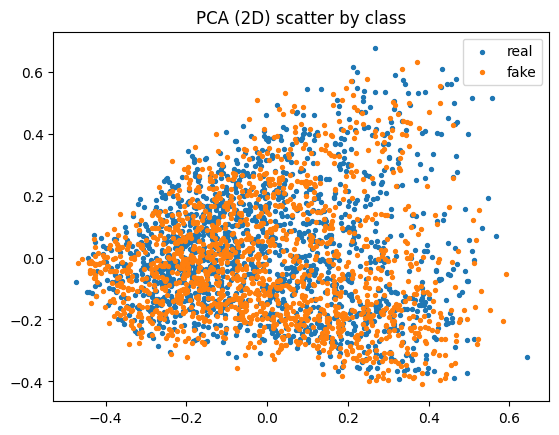

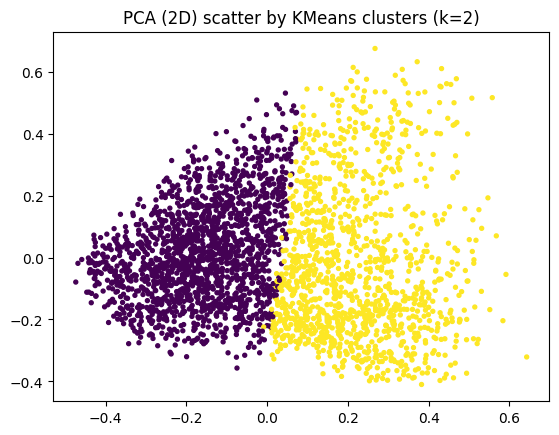

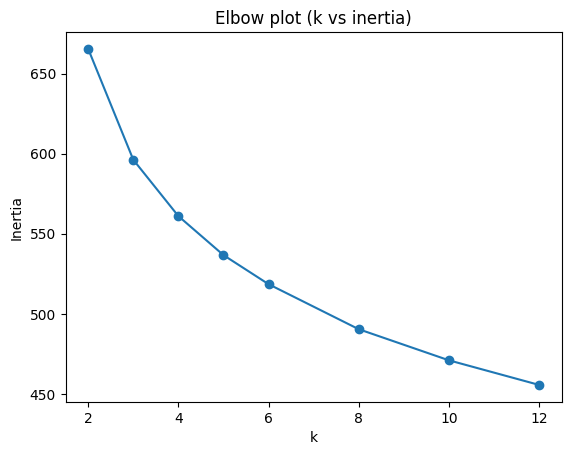

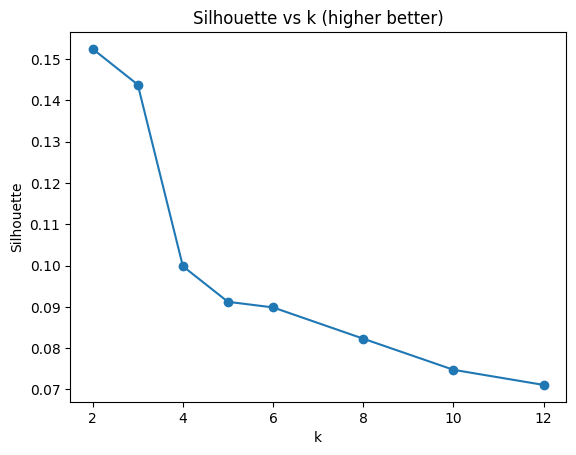

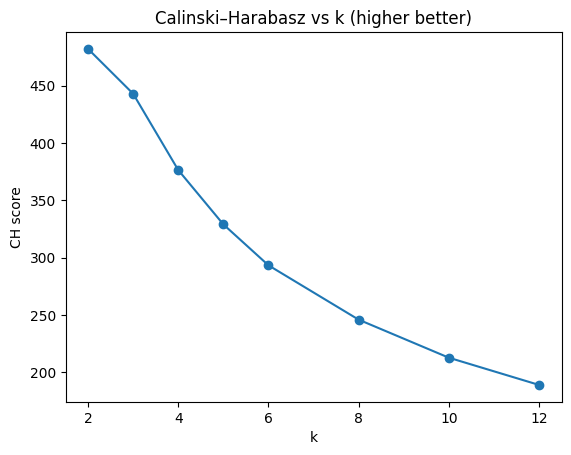

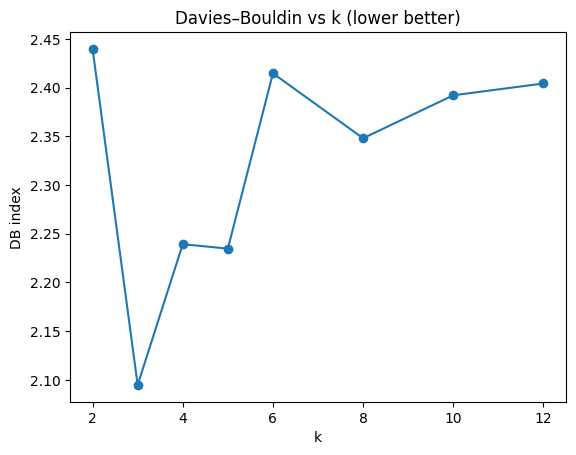


Cluster composition (sorted):


label,real,fake,total
cluster,,,
0,871,868,1739
1,629,632,1261


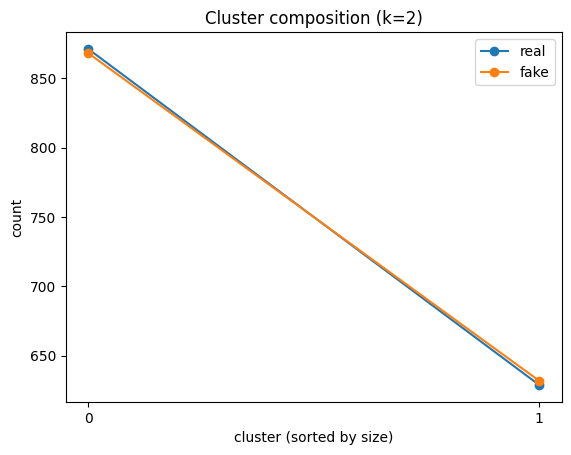


Fake technique counts (top clusters):


tech,copy_move,inpaint,postproc,splicing,stargan_tiles,swap_like
cluster,,,,,,
0,140,135,136,108,142,207
1,111,111,110,51,150,99


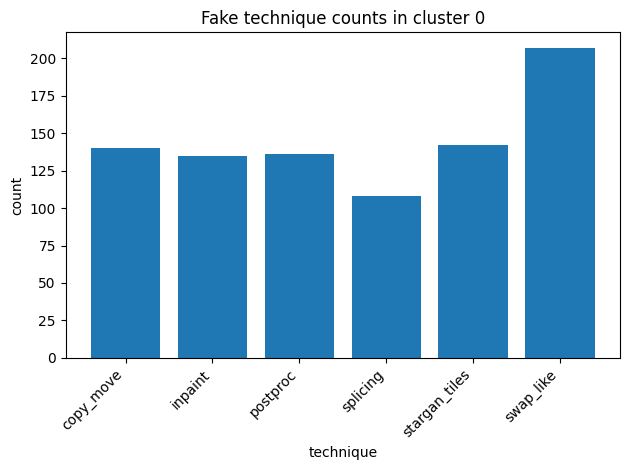

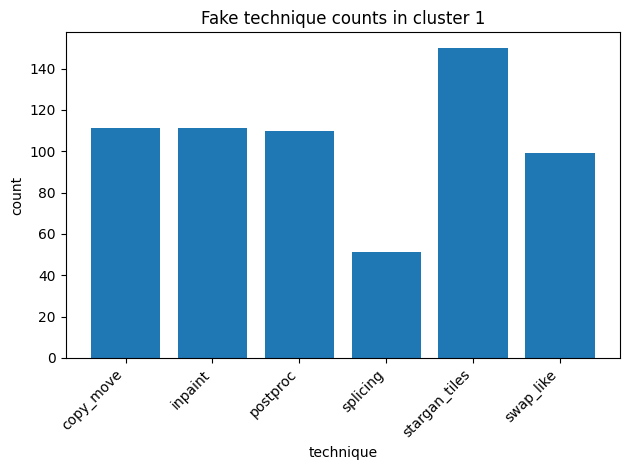

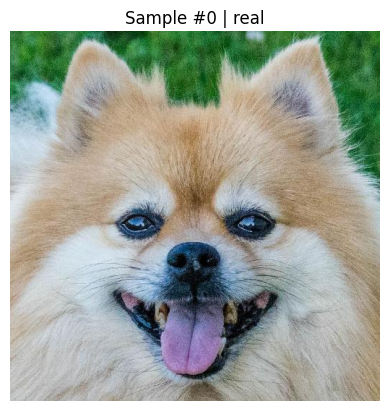

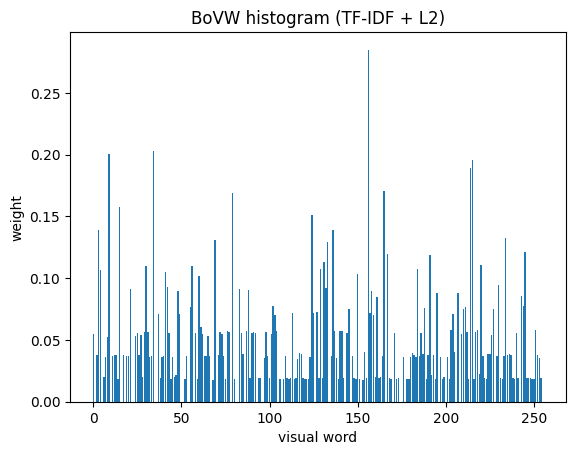

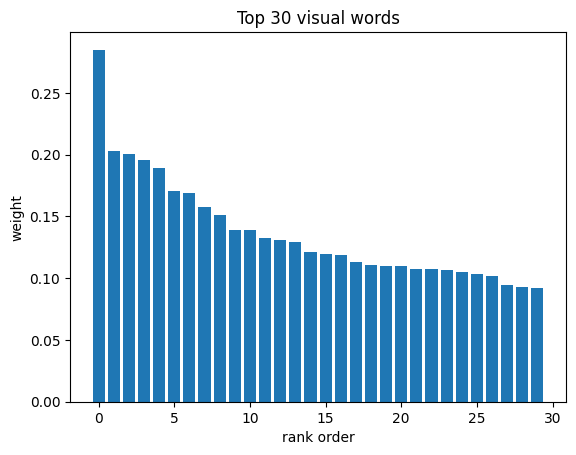

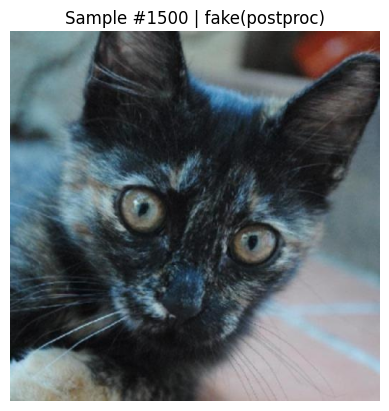

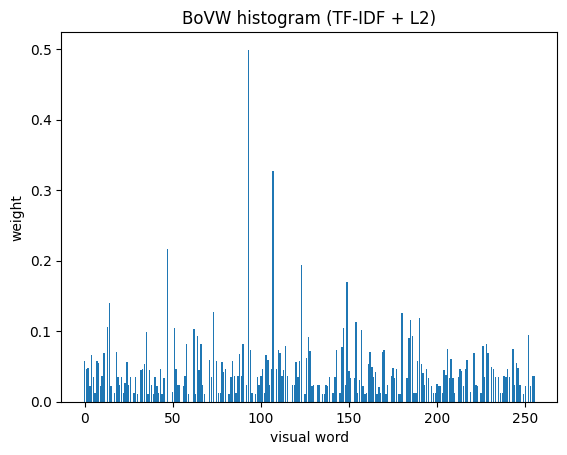

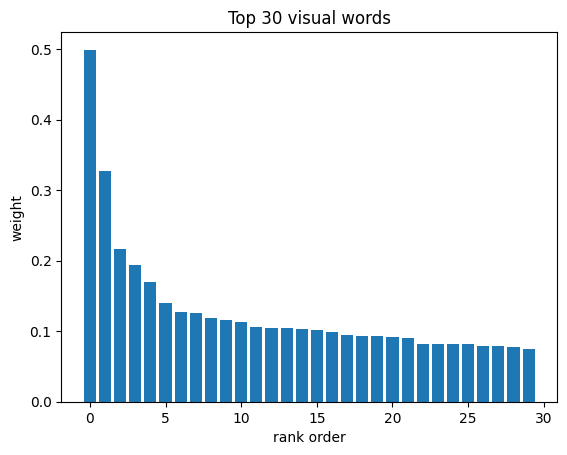


Done: generated K-Means EDA charts and BoVW visualizations.


In [ ]:
# K-MEANS EDA + BoVW VIS (TRAIN SPLIT)
# Charts: PCA scatter by class, PCA scatter by cluster (best k), elbow, silhouette, CH, DB,
# cluster composition (real/fake), fake-tech preferences, and image->BoVW histogram demo.
# Uses matplotlib (no seaborn), one chart per figure, no explicit colors.

import os, random, gc
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt

from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import normalize
from joblib import dump, load

# ---------------------------
# CONFIG
# ---------------------------
random.seed(42); np.random.seed(42)

BASE          = Path("/content/stargan-v2")
TRAIN_REAL    = BASE/"data/combined_balanced/train/real"
TRAIN_FAKE    = BASE/"data/combined_balanced/train/fake"
CACHE_DIR     = BASE/"eda_cache"   # caches codebook, PCA, IDF, etc.
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Sampling controls
MAX_PER_CLASS         = 1500     # cap per class for speed; set None to use all
RESIZE_MAX_SIDE       = 512      # long side resize for descriptor extraction
MAX_DESCS_PER_IMAGE   = 500
MAX_TOTAL_DESCRIPTORS = 200_000  # cap for codebook fitting

# Codebook (visual words)
CODEBOOK_K     = 256
CODEBOOK_PATH  = CACHE_DIR/f"codebook_K{CODEBOOK_K}.joblib"

# TF-IDF (on BoVW histograms)
USE_TFIDF      = True
IDF_PATH       = CACHE_DIR/f"idf_K{CODEBOOK_K}.npy"

# PCA
PCA_DIM_CLUSTER = 50     # for clustering/validity
PCA_DIM_PLOT    = 2      # for 2D scatter
PCA_CLUSTER_PATH = CACHE_DIR/f"pca_{PCA_DIM_CLUSTER}.joblib"
PCA_PLOT_PATH    = CACHE_DIR/f"pca_{PCA_DIM_PLOT}.joblib"

# K choices for elbow/validity
K_LIST = [2,3,4,5,6,8,10,12]

# ---------------------------
# HELPERS
# ---------------------------
EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}

def list_images(d: Path):
    return [p for p in d.iterdir() if p.is_file() and p.suffix.lower() in EXTS] if d.exists() else []

def load_gray_resize(p: Path, max_side=RESIZE_MAX_SIDE):
    im = cv2.imread(str(p), cv2.IMREAD_COLOR)
    if im is None: return None
    h,w = im.shape[:2]; s = max(h,w)
    if s > max_side:
        sc = max_side/float(s)
        im = cv2.resize(im, (int(w*sc), int(h*sc)), interpolation=cv2.INTER_AREA)
    return cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

def get_detector():
    # Try SIFT (opencv-contrib). Fallback to ORB automatically.
    try:
        return cv2.SIFT_create(), "SIFT"
    except Exception:
        return cv2.ORB_create(nfeatures=1000, fastThreshold=10), "ORB"

def extract_desc(detector, gray):
    kps, desc = detector.detectAndCompute(gray, None)
    if desc is None or len(kps)==0:
        try: dlen = detector.descriptorSize()
        except Exception: dlen = 32
        return np.empty((0, dlen), np.float32)
    if desc.dtype != np.float32: desc = desc.astype(np.float32)
    return desc

def parse_fake_tech(p: Path):
    # filename like "name__tech.ext" -> "tech"
    s = p.stem
    return s.split("__")[-1] if "__" in s else "unknown"

# ---------------------------
# 1) Sample TRAIN images
# ---------------------------
reals = list_images(TRAIN_REAL)
fakes = list_images(TRAIN_FAKE)
random.shuffle(reals); random.shuffle(fakes)
if MAX_PER_CLASS is not None:
    reals = reals[:MAX_PER_CLASS]
    fakes = fakes[:MAX_PER_CLASS]

X_paths = reals + fakes
y       = np.array([0]*len(reals) + [1]*len(fakes), dtype=np.int64)  # 0=real, 1=fake
tech    = [("real" if i < len(reals) else parse_fake_tech(p)) for i,p in enumerate(X_paths)]

print(f"Sampled TRAIN: real={len(reals)} fake={len(fakes)} total={len(X_paths)}")
assert len(X_paths)>0, "No images found. Make sure /content/stargan-v2/data/combined_balanced/train exists."

# ---------------------------
# 2) Codebook (MiniBatchKMeans) for BoVW
# ---------------------------
det, det_name = get_detector()
print("Feature detector:", det_name)

if CODEBOOK_PATH.exists():
    codebook = load(CODEBOOK_PATH)
    if getattr(codebook,"n_clusters",None) != CODEBOOK_K:
        codebook = None
else:
    codebook = None

if codebook is None:
    print("Fitting visual codebook...")
    all_descs, total = [], 0
    for p in X_paths:
        g = load_gray_resize(p)
        if g is None: continue
        d = extract_desc(det, g)
        if d.shape[0]==0: continue
        if d.shape[0] > MAX_DESCS_PER_IMAGE:
            idx = np.random.choice(d.shape[0], MAX_DESCS_PER_IMAGE, replace=False)
            d = d[idx]
        all_descs.append(d)
        total += d.shape[0]
        if total >= MAX_TOTAL_DESCRIPTORS: break
    assert len(all_descs)>0, "No descriptors to fit codebook."
    D = np.vstack(all_descs).astype(np.float32)
    codebook = MiniBatchKMeans(n_clusters=CODEBOOK_K, batch_size=4096, random_state=42, reassignment_ratio=0.01)
    codebook.fit(D)
    dump(codebook, CODEBOOK_PATH)
    del D, all_descs; gc.collect()
    print("Saved codebook:", CODEBOOK_PATH)
else:
    print("Loaded codebook:", CODEBOOK_PATH.name)

# ---------------------------
# 3) BoVW histograms (TF-IDF + L2)
# ---------------------------
def image_hist(p: Path):
    g = load_gray_resize(p)
    if g is None: return np.zeros((CODEBOOK_K,), np.float32)
    d = extract_desc(det, g)
    if d.shape[0]==0: return np.zeros((CODEBOOK_K,), np.float32)
    words = codebook.predict(d)
    return np.bincount(words, minlength=CODEBOOK_K).astype(np.float32)

H = np.zeros((len(X_paths), CODEBOOK_K), np.float32)
for i,p in enumerate(X_paths):
    H[i] = image_hist(p)
print("BoVW matrix:", H.shape)

# IDF (if not cached, compute from current sample)
if USE_TFIDF:
    if IDF_PATH.exists():
        idf = np.load(IDF_PATH)
        if idf.shape[0] != CODEBOOK_K:
            df = (H>0).sum(axis=0); idf = np.log((H.shape[0]+1)/(df+1))+1.0; np.save(IDF_PATH, idf)
    else:
        df = (H>0).sum(axis=0); idf = np.log((H.shape[0]+1)/(df+1))+1.0; np.save(IDF_PATH, idf)
else:
    idf = np.ones((CODEBOOK_K,), np.float32)

H_tfidf = H * idf.reshape(1,-1)
H_norm  = normalize(H_tfidf, norm="l2")

# ---------------------------
# 4) PCA (50D for clustering, 2D for plots)
# ---------------------------
if PCA_CLUSTER_PATH.exists():
    pca_cluster = load(PCA_CLUSTER_PATH)
    if getattr(pca_cluster,"n_components",None) != PCA_DIM_CLUSTER:
        pca_cluster = None
else:
    pca_cluster = None

if pca_cluster is None:
    pca_cluster = PCA(n_components=PCA_DIM_CLUSTER, random_state=42)
    X_cluster = pca_cluster.fit_transform(H_norm)
    dump(pca_cluster, PCA_CLUSTER_PATH)
else:
    X_cluster = pca_cluster.transform(H_norm)

if PCA_PLOT_PATH.exists():
    pca_plot = load(PCA_PLOT_PATH)
    if getattr(pca_plot,"n_components",None) != PCA_DIM_PLOT:
        pca_plot = None
else:
    pca_plot = None

if pca_plot is None:
    pca_plot = PCA(n_components=PCA_DIM_PLOT, random_state=42)
    X_plot = pca_plot.fit_transform(H_norm)
    dump(pca_plot, PCA_PLOT_PATH)
else:
    X_plot = pca_plot.transform(H_norm)

print("PCA dims:", X_cluster.shape, X_plot.shape)

# ---------------------------
# 5) KMeans elbow + validity (on PCA-50)
# ---------------------------
inertias, sils, chs, dbs = [], [], [], []

# subsample for silhouette if big
SIL_MAX = 4000
if X_cluster.shape[0] > SIL_MAX:
    idx_sil = np.random.choice(X_cluster.shape[0], SIL_MAX, replace=False)
    X_for_sil = X_cluster[idx_sil]
else:
    X_for_sil = X_cluster

for k in K_LIST:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
    labels_k = km.labels_
    # validity scores
    try:   sil = silhouette_score(X_for_sil, km.predict(X_for_sil))
    except Exception: sil = np.nan
    try:   ch  = calinski_harabasz_score(X_cluster, labels_k)
    except Exception: ch  = np.nan
    try:   db  = davies_bouldin_score(X_cluster, labels_k)
    except Exception: db  = np.nan
    sils.append(sil); chs.append(ch); dbs.append(db)

# pick best k by silhouette (fallback to 2)
k_best = K_LIST[int(np.nanargmax(np.array(sils)))] if np.any(~np.isnan(sils)) else 2
km_best = KMeans(n_clusters=k_best, n_init=10, random_state=42).fit(X_cluster)
clusters = km_best.labels_

# ---------------------------
# 6) CHARTS
# ---------------------------
plt.figure()
plt.scatter(X_plot[y==0,0], X_plot[y==0,1], s=8, label="real")
plt.scatter(X_plot[y==1,0], X_plot[y==1,1], s=8, label="fake")
plt.title("PCA (2D) scatter by class")
plt.legend(); plt.show()

plt.figure()
plt.scatter(X_plot[:,0], X_plot[:,1], s=8, c=clusters)
plt.title(f"PCA (2D) scatter by KMeans clusters (k={k_best})")
plt.show()

plt.figure()
plt.plot(K_LIST, inertias, marker='o')
plt.title("Elbow plot (k vs inertia)")
plt.xlabel("k"); plt.ylabel("Inertia"); plt.show()

plt.figure()
plt.plot(K_LIST, sils, marker='o')
plt.title("Silhouette vs k (higher better)")
plt.xlabel("k"); plt.ylabel("Silhouette"); plt.show()

plt.figure()
plt.plot(K_LIST, chs, marker='o')
plt.title("Calinski–Harabasz vs k (higher better)")
plt.xlabel("k"); plt.ylabel("CH score"); plt.show()

plt.figure()
plt.plot(K_LIST, dbs, marker='o')
plt.title("Davies–Bouldin vs k (lower better)")
plt.xlabel("k"); plt.ylabel("DB index"); plt.show()

# ---------------------------
# 7) Cluster composition & fake-tech preference
# ---------------------------
import pandas as pd
df = pd.DataFrame({
    "path": [str(p) for p in X_paths],
    "label": y,
    "cluster": clusters,
    "tech": tech
})
# composition
comp = df.groupby(["cluster","label"]).size().unstack(fill_value=0).rename(columns={0:"real",1:"fake"})
comp["total"] = comp.sum(axis=1)
comp = comp.sort_values("total", ascending=False)
print("\nCluster composition (sorted):")
display(comp)

# plot real/fake counts by cluster index (sorted)
plt.figure()
x = np.arange(len(comp.index))
plt.plot(x, comp["real"].values, marker='o', label="real")
plt.plot(x, comp["fake"].values, marker='o', label="fake")
plt.title(f"Cluster composition (k={k_best})")
plt.xlabel("cluster (sorted by size)"); plt.ylabel("count")
plt.xticks(x, comp.index.astype(str))
plt.legend(); plt.show()

# fake tech preference (top 3 clusters by size)
top_clusters = comp.index.tolist()[:3]
tech_counts = (df[df["label"]==1].groupby(["cluster","tech"]).size().unstack(fill_value=0))
tech_counts = tech_counts.loc[tech_counts.index.intersection(top_clusters)]
print("\nFake technique counts (top clusters):")
display(tech_counts)

for cl in tech_counts.index:
    row = tech_counts.loc[cl]
    plt.figure()
    plt.bar(range(len(row.index)), row.values)
    plt.title(f"Fake technique counts in cluster {cl}")
    plt.xlabel("technique"); plt.ylabel("count")
    plt.xticks(range(len(row.index)), row.index, rotation=45, ha='right')
    plt.tight_layout(); plt.show()

# ---------------------------
# 8) Visualize: IMAGE → BoVW histogram
# ---------------------------
def visualize_bovw(idx):
    p = X_paths[idx]
    lab = "fake("+parse_fake_tech(p)+")" if y[idx]==1 else "real"
    im = cv2.imread(str(p), cv2.IMREAD_COLOR)
    if im is not None:
        plt.figure()
        plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        plt.title(f"Sample #{idx} | {lab}")
        plt.axis('off'); plt.show()
    # Full histogram
    plt.figure()
    plt.bar(np.arange(CODEBOOK_K), H_norm[idx])
    plt.title("BoVW histogram (TF-IDF + L2)"); plt.xlabel("visual word"); plt.ylabel("weight")
    plt.show()
    # Top words
    topk = 30
    inds = np.argsort(-H_norm[idx])[:topk]
    vals = H_norm[idx][inds]
    plt.figure()
    plt.bar(np.arange(topk), vals)
    plt.title("Top 30 visual words"); plt.xlabel("rank order"); plt.ylabel("weight")
    plt.show()

# Build normalized hist (already computed above)
# H_norm was created, but if memory freed, rebuild quickly:
try:
    H_norm
except NameError:
    H_tfidf = H * idf.reshape(1,-1)
    H_norm = normalize(H_tfidf, norm='l2')

# show one real and one fake example
if np.any(y==0): visualize_bovw(int(np.where(y==0)[0][0]))
if np.any(y==1): visualize_bovw(int(np.where(y==1)[0][0]))

print("\nDone: generated K-Means EDA charts and BoVW visualizations.")


In [ ]:
# === BoVW + PCA + Image KMeans for VAL & HOLDOUT ===
# - Reads:  /content/stargan-v2/data/combined_balanced/{val,holdout}/{real,fake}
# - Loads TRAIN artifacts: kmeans codebook + PCA from /content/stargan-v2/bovw
# - Writes: CSV + .npy under /content/stargan-v2/bovw for each split
# - Includes pre-preprocessing image stats and km(10) cluster labels

import os, re, gc, math, glob, joblib, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans

# -------------------
# Config
# -------------------
BASE        = Path("/content/stargan-v2")
DATA_ROOT   = BASE/"data/combined_balanced"         # expects {val,holdout}/{real,fake}
ARTIFACTS   = BASE/"bovw"                            # where TRAIN saved codebook & PCA
SPLITS      = ["val", "holdout"]                     # which splits to process
CLASSES     = ["real","fake"]
EXTS        = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
MAX_SIDE    = 512                                    # resize longer side before descriptor
RNG_SEED    = 42
KM_IMG_K    = 10                                     # image-level k-means on PCA features

np.random.seed(RNG_SEED)

# -------------------
# Find/load TRAIN artifacts (codebook + PCA)
# -------------------
def pick_artifacts(artifacts_dir: Path):
    # Prefer SIFT artifacts; fall back to any available
    km_files = sorted(glob.glob(str(artifacts_dir/"kmeans_*_K*.joblib")))
    pca_files = sorted(glob.glob(str(artifacts_dir/"pca_*_K*_to*.joblib")))
    if not km_files or not pca_files:
        raise FileNotFoundError(f"No TRAIN artifacts found in {artifacts_dir}. "
                                f"Expected kmeans_*.joblib and pca_*.joblib.")
    # Try to match K in filenames
    def parse_k(fname):
        m = re.search(r"_K(\d+)", Path(fname).stem)
        return int(m.group(1)) if m else None
    km_by_k  = {parse_k(f): f for f in km_files}
    pca_by_k = {parse_k(f): f for f in pca_files}
    # choose intersection with largest K (or any)
    Ks = sorted(set(km_by_k.keys()) & set(pca_by_k.keys()))
    if not Ks:
        # no matching K; just take the first of each
        km_path = km_files[0]
        pca_path = pca_files[0]
    else:
        Ksel = max(Ks)  # pick max shared K (or change to min if you prefer)
        km_path  = km_by_k[Ksel]
        pca_path = pca_by_k[Ksel]
    # parse detector name and dims
    det = "SIFT" if "SIFT" in Path(km_path).name else ("ORB" if "ORB" in Path(km_path).name else "DET")
    m_dims = re.search(r"_to(\d+)$", Path(pca_path).stem)
    pca_dims = int(m_dims.group(1)) if m_dims else None
    # Try to load an optional IDF vector (computed during TRAIN). If absent, we’ll skip TF-IDF.
    idf_candidates = list(artifacts_dir.glob(f"idf_{det}_K*.npy"))
    idf = None
    if idf_candidates:
        # choose idf with matching K if possible
        idf_by_k = {parse_k(str(p)): p for p in idf_candidates}
        K_used = parse_k(km_path)
        if K_used in idf_by_k:
            idf = np.load(idf_by_k[K_used])
        else:
            idf = np.load(idf_candidates[0])
    return km_path, pca_path, det, pca_dims, idf

KM_PATH, PCA_PATH, DET_NAME, PCA_DIMS, IDF_VEC = pick_artifacts(ARTIFACTS)
print(f"Using TRAIN artifacts:\n - {KM_PATH}\n - {PCA_PATH}\nDetector: {DET_NAME} | PCA dims: {PCA_DIMS} | TF-IDF: {'Yes' if IDF_VEC is not None else 'No'}")

kmeans_codebook = joblib.load(KM_PATH)   # MiniBatchKMeans from TRAIN
pca_model       = joblib.load(PCA_PATH)  # PCA from TRAIN
K               = int(re.search(r"_K(\d+)", Path(KM_PATH).stem).group(1))

# -------------------
# Helpers
# -------------------
def list_images(root: Path):
    if not root.exists(): return []
    return [p for p in root.iterdir() if p.is_file() and p.suffix.lower() in EXTS]

def load_gray_resize_for_desc(p: Path, max_side=MAX_SIDE):
    img = cv2.imread(str(p), cv2.IMREAD_COLOR)
    if img is None: return None
    h, w = img.shape[:2]
    s = max(h, w)
    if s > max_side:
        scale = max_side / float(s)
        img = cv2.resize(img, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray

def pre_stats(p: Path):
    # pre-preprocessing: on original file (no resize)
    try:
        bgr = cv2.imread(str(p), cv2.IMREAD_COLOR)
        if bgr is None:
            return dict(width=-1, height=-1, aspect_ratio=np.nan,
                        brightness=np.nan, contrast=np.nan,
                        sharpness_laplacian_var=np.nan,
                        symmetry_l1_mean=np.nan,
                        filesize_bytes=p.stat().st_size if p.exists() else -1)
        h, w = bgr.shape[:2]
        ar = w / max(h, 1)
        g  = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
        brightness = float(g.mean())
        contrast   = float(g.std())
        lap = cv2.Laplacian(g, cv2.CV_64F)
        sharp_var = float(lap.var())
        # symmetry: mean L1 diff between left/right halves normalized to [0,1]
        mid = w // 2
        left  = g[:, :mid]
        right = g[:, w - mid:][:, ::-1]  # mirror
        if left.size and right.size:
            # normalize by intensity range to keep 0..1-ish scale
            denom = max(1.0, float(g.max() - g.min()))
            sym = float(np.mean(np.abs(left.astype(np.float32) - right.astype(np.float32))) / denom)
        else:
            sym = np.nan
        size_bytes = p.stat().st_size if p.exists() else -1
        return dict(width=w, height=h, aspect_ratio=ar, brightness=brightness,
                    contrast=contrast, sharpness_laplacian_var=sharp_var,
                    symmetry_l1_mean=sym, filesize_bytes=size_bytes)
    except Exception:
        return dict(width=-1, height=-1, aspect_ratio=np.nan,
                    brightness=np.nan, contrast=np.nan,
                    sharpness_laplacian_var=np.nan,
                    symmetry_l1_mean=np.nan,
                    filesize_bytes=-1)

def get_detector():
    # Use SIFT if available; else ORB
    try:
        sift = cv2.SIFT_create()
        return sift, "SIFT"
    except Exception:
        orb = cv2.ORB_create(nfeatures=1000, fastThreshold=10)
        return orb, "ORB"

def extract_desc(det, gray):
    kps, desc = det.detectAndCompute(gray, None)
    if desc is None or len(kps) == 0:
        # choose a compatible width (SIFT=128, ORB=32)
        d = 128 if hasattr(det, "descriptorSize") and det.descriptorSize() else (desc.shape[1] if desc is not None else 128)
        return np.empty((0, d), dtype=np.float32)
    if desc.dtype != np.float32:
        desc = desc.astype(np.float32)
    return desc

def hist_for_image(p: Path, det):
    gray = load_gray_resize_for_desc(p)
    if gray is None:
        return np.zeros((K,), dtype=np.float32)
    desc = extract_desc(det, gray)
    if desc.shape[0] == 0:
        return np.zeros((K,), dtype=np.float32)
    words = kmeans_codebook.predict(desc)
    h = np.bincount(words, minlength=K).astype(np.float32)
    return h

def apply_tfidf_and_norm(H, idf=None):
    # If we have TRAIN's IDF, use it; else just L2 normalize counts.
    if idf is not None:
        H = H * idf.reshape(1, -1)
    H = normalize(H, norm="l2")
    return H

# -------------------
# Main per-split processing
# -------------------
detector, det_name = get_detector()
print(f"Local descriptor for inference: {det_name}")

for split in SPLITS:
    split_root = DATA_ROOT/split
    real_paths = list_images(split_root/"real")
    fake_paths = list_images(split_root/"fake")
    paths  = real_paths + fake_paths
    labels = [0]*len(real_paths) + [1]*len(fake_paths)

    print(f"\n=== {split.upper()} ===")
    print(f"Found: real={len(real_paths)} fake={len(fake_paths)} total={len(paths)}")
    assert len(paths) > 0, f"No images found in {split_root}."

    # 1) Pre-preprocessing stats
    rows = []
    print("Computing pre-preprocessing stats...")
    for p, lab in tqdm(list(zip(paths, labels)), total=len(paths)):
        st = pre_stats(p)
        st["path"]  = str(p)
        st["label"] = int(lab)
        rows.append(st)

    df = pd.DataFrame(rows)

    # 2) BoVW histograms via TRAIN codebook
    print("Building BoVW histograms...")
    H = np.zeros((len(paths), K), dtype=np.float32)
    for i, p in enumerate(tqdm(paths)):
        H[i] = hist_for_image(p, detector)

    H_norm = apply_tfidf_and_norm(H, idf=IDF_VEC)

    # 3) PCA transform using TRAIN PCA
    print("Applying PCA transform...")
    X_pca = pca_model.transform(H_norm)

    # 4) Image-level KMeans (k=10) on PCA features (unsupervised EDA)
    print(f"Fitting image-level KMeans(k={KM_IMG_K}) on PCA features...")
    km_img = KMeans(n_clusters=KM_IMG_K, random_state=RNG_SEED, n_init=10)
    km_labels = km_img.fit_predict(X_pca)
    # optional distances to cluster centers
    dists = km_img.transform(X_pca)

    # 5) Save arrays & CSV
    out_pref = ARTIFACTS
    (out_pref).mkdir(parents=True, exist_ok=True)

    np.save(out_pref/f"H_{det_name}_K{K}_{split}.npy", H_norm)
    np.save(out_pref/f"X_pca_{det_name}_K{K}_{split}.npy", X_pca)
    np.save(out_pref/f"y_{split}.npy", np.array(labels, dtype=np.int64))
    np.save(out_pref/f"km_img_labels_k{KM_IMG_K}_{split}.npy", km_labels)
    np.save(out_pref/f"km_img_dists_k{KM_IMG_K}_{split}.npy", dists)

    # Add compact feature columns to CSV (avoid huge 100s of columns):
    # keep just: path/label + pre-stats + cluster label + first 10 PCA comps
    df["km_img_k10"] = km_labels
    keep_pcs = min(10, X_pca.shape[1])
    for j in range(keep_pcs):
        df[f"pca_{j}"] = X_pca[:, j]
    csv_path = out_pref/f"image_features_{split}.csv"
    df.to_csv(csv_path, index=False)

    # 6) Quick diagnostics
    print(f"Wrote arrays to: {out_pref}")
    print(f"Wrote CSV: {csv_path}")
    print(f"Shapes: H={H_norm.shape} | X_pca={X_pca.shape} | dists={dists.shape}")
    print("Label counts:", dict(pd.Series(labels).map({0:"real",1:"fake"}).value_counts()))

    # Free memory per split
    del rows, df, H, H_norm, X_pca, km_img, km_labels, dists
    gc.collect()

print("\n=== DONE ===")


Using TRAIN artifacts:
 - /content/stargan-v2/bovw/kmeans_SIFT_K256.joblib
 - /content/stargan-v2/bovw/pca_SIFT_K256_to128.joblib
Detector: SIFT | PCA dims: 128 | TF-IDF: Yes
Local descriptor for inference: SIFT

=== VAL ===
Found: real=2380 fake=2330 total=4710
Computing pre-preprocessing stats...


100%|██████████| 4710/4710 [00:45<00:00, 103.89it/s]


Building BoVW histograms...


100%|██████████| 4710/4710 [10:30<00:00,  7.47it/s]


Applying PCA transform...
Fitting image-level KMeans(k=10) on PCA features...
Wrote arrays to: /content/stargan-v2/bovw
Wrote CSV: /content/stargan-v2/bovw/image_features_val.csv
Shapes: H=(4710, 256) | X_pca=(4710, 128) | dists=(4710, 10)
Label counts: {'real': np.int64(2380), 'fake': np.int64(2330)}

=== HOLDOUT ===
Found: real=2275 fake=2275 total=4550
Computing pre-preprocessing stats...


100%|██████████| 4550/4550 [00:41<00:00, 109.56it/s]


Building BoVW histograms...


100%|██████████| 4550/4550 [10:17<00:00,  7.36it/s]


Applying PCA transform...
Fitting image-level KMeans(k=10) on PCA features...
Wrote arrays to: /content/stargan-v2/bovw
Wrote CSV: /content/stargan-v2/bovw/image_features_holdout.csv
Shapes: H=(4550, 256) | X_pca=(4550, 128) | dists=(4550, 10)
Label counts: {'real': np.int64(2275), 'fake': np.int64(2275)}

=== DONE ===


In [ ]:
# Create parent folders on Drive
!mkdir -p "/content/drive/MyDrive/stargan-v2/bovw"


# Sync from Colab storage -> Drive
!rsync -a "/content/stargan-v2/bovw" \
         "/content/drive/MyDrive/stargan-v2/bovw/"
